# Datová analýza

Moje vybraná síť je síť odkazů komunit stránky [Reddit](https://www.reddit.com/). Tato stránka je složena z jednotlivých menších komunit, které se nazývají sub-reddity, které reprezentují uzly. Právě příspěvky v těchto menších sub-redditech se někdy odkazovali na jiné sub-reddity, což v naší sítí tvoří hrany mezi uzly. Síť je **orientovaná**, **s ohodnocením hran**, **časová** a **s atributy uzlů a hran**.

**Statistika sítě od autora datasetu:**

| Statistika                 | Hodnota                         |
|----------------------------|---------------------------------|
| Počet uzlů (subreddity)    | 55 863                          |
| Počet hran (hyperlinky)    | 858 490                         |
| Ohodnocení hran            | -1 nebo +1                      |
| Atributy hran              | Vektory textových vlastností    |
| Časové období              | leden 2014 – duben 2017         |


Vidíme, že ohodnocení hran může být buďto -1 nebo +1, což značí, zda se jedná o pozitivní nebo negativní odkaz mezi dvěma sub-reddity. Atributy hran jsou reprezentovány vektory textových vlastností, které obsahují informace o obsahu příspěvků, které vytvořily danou hyperlinku mezi dvěma sub-reddity. Tyto vektory mohou být využity pro analýzu témat, sentimentu nebo dalších charakteristik spojených s danými odkazy než o analýzu samotné struktury sítě.

Spíše vidíme, že se jedná síť převážně pro oblast analýzy sentimentu a vztahů mezi online komunitami spojené s hlubokým učením. My si pouze vezmeme jednotlivé hrany, uzly a časové období pro naši analýzu.

Odkaz na dataset nelznete [zde](https://snap.stanford.edu/data/soc-RedditHyperlinks.html).

## Načtení knihoven

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from multiprocessing import Pool
import multiprocessing as mp
from pathlib import Path
import random
import numpy as np
import os
import seaborn as sns
import tabulate

random.seed(42)
np.random.seed(42)

In [2]:
SAVE_PATH = Path("../results/project_analysis")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

## Načtení datasetu

Dataset obsahuje dva soubory, jeden s odkazy z titulků příspěvků a druhý s odkazy z těla příspěvků. Jelikož v každém z těchto souborů jsou různé odkazy, sloučením dostaneme kompletní síť.

Součin počtu uzlů a průměrného stupně sítě je pseudo-metrika pro výběr datasetu, který musel být větší než **500 000**.

### Body

In [3]:
from tabulate import tabulate

df_reddit_body = pd.read_csv('../data/soc-redditHyperlinks-body.tsv', sep='\t')

df_reddit_body = df_reddit_body[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]

G_body = nx.from_pandas_edgelist(
    df_reddit_body,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph
)

num_nodes_body = G_body.number_of_nodes()
num_edges_body = G_body.number_of_edges()

avg_out_degree = sum(dict(G_body.out_degree()).values()) / num_nodes_body
avg_in_degree = sum(dict(G_body.in_degree()).values()) / num_nodes_body
avg_total_degree = avg_in_degree + avg_out_degree  # or 2*num_edges_body / num_nodes_body

stats = [
    ["Nodes", f"{num_nodes_body:,}"],
    ["Edges", f"{num_edges_body:,}"],
    ["Average Out-Degree", f"{avg_out_degree:,.4f}"],
    ["Average In-Degree", f"{avg_in_degree:,.4f}"],
    ["Average Total Degree", f"{avg_total_degree:,.4f}"],
    ["Multiplication of Nodes and Average Total Degree", f"{num_nodes_body * avg_total_degree:,}"],
    ["Directed", str(G_body.is_directed())]
]

print(tabulate(tabular_data=stats, headers=["Metric", "Value"], tablefmt="simple_grid"))

┌──────────────────────────────────────────────────┬───────────┐
│ Metric                                           │ Value     │
├──────────────────────────────────────────────────┼───────────┤
│ Nodes                                            │ 35,776    │
├──────────────────────────────────────────────────┼───────────┤
│ Edges                                            │ 137,821   │
├──────────────────────────────────────────────────┼───────────┤
│ Average Out-Degree                               │ 3.8523    │
├──────────────────────────────────────────────────┼───────────┤
│ Average In-Degree                                │ 3.8523    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Total Degree                             │ 7.7047    │
├──────────────────────────────────────────────────┼───────────┤
│ Multiplication of Nodes and Average Total Degree │ 275,642.0 │
├──────────────────────────────────────────────────┼───────────┤
│ Directed               

### Title

In [4]:
from tabulate import tabulate

df_reddit_title = pd.read_csv('../data/soc-redditHyperlinks-title.tsv', sep='\t')

df_reddit_title = df_reddit_title[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]

G_title = nx.from_pandas_edgelist(
    df_reddit_title,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph
)

num_nodes_title = G_title.number_of_nodes()
num_edges_title = G_title.number_of_edges()

avg_out_degree_title = sum(dict(G_title.out_degree()).values()) / num_nodes_title
avg_in_degree_title = sum(dict(G_title.in_degree()).values()) / num_nodes_title
avg_total_degree_title = avg_in_degree_title + avg_out_degree_title  # or 2*num_edges_title / num_nodes_title

stats = [
    ["Nodes", f"{num_nodes_title:,}"],
    ["Edges", f"{num_edges_title:,}"],
    ["Average Out-Degree", f"{avg_out_degree_title:,.4f}"],
    ["Average In-Degree", f"{avg_in_degree_title:,.4f}"],
    ["Average Total Degree", f"{avg_total_degree_title:,.4f}"],
    ["Multiplication of Nodes and Average Total Degree", f"{num_nodes_title * avg_total_degree_title:,}"],
    ["Directed", str(G_title.is_directed())]
]

print(tabulate(tabular_data=stats, headers=["Metric", "Value"], tablefmt="simple_grid"))

┌──────────────────────────────────────────────────┬───────────┐
│ Metric                                           │ Value     │
├──────────────────────────────────────────────────┼───────────┤
│ Nodes                                            │ 54,075    │
├──────────────────────────────────────────────────┼───────────┤
│ Edges                                            │ 234,792   │
├──────────────────────────────────────────────────┼───────────┤
│ Average Out-Degree                               │ 4.3420    │
├──────────────────────────────────────────────────┼───────────┤
│ Average In-Degree                                │ 4.3420    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Total Degree                             │ 8.6839    │
├──────────────────────────────────────────────────┼───────────┤
│ Multiplication of Nodes and Average Total Degree │ 469,584.0 │
├──────────────────────────────────────────────────┼───────────┤
│ Directed               

### Dohromady

In [5]:
from tabulate import tabulate

df_reddit_merged = pd.concat([
    df_reddit_body[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']],
    df_reddit_title[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP']]
], ignore_index=True)

df_reddit_merged = df_reddit_merged.drop_duplicates(subset=['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'TIMESTAMP'])

G_merged = nx.from_pandas_edgelist(
    df_reddit_merged,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph()  # type: ignore
)  # pyright: ignore[reportCallIssue]

num_nodes_merged = G_merged.number_of_nodes()
num_edges_merged = G_merged.number_of_edges()

# Average degrees
avg_in_degree_merged = sum(dict(G_merged.in_degree()).values()) / num_nodes_merged
avg_out_degree_merged = sum(dict(G_merged.out_degree()).values()) / num_nodes_merged
avg_total_degree_merged = avg_in_degree_merged + avg_out_degree_merged  # or 2*num_edges_merged / num_nodes_merged

# Print results
stats = [
    ["Nodes", f"{num_nodes_merged:,}"],
    ["Edges", f"{num_edges_merged:,}"],
    ["Average In-Degree", f"{avg_in_degree_merged:,.4f}"],
    ["Average Out-Degree", f"{avg_out_degree_merged:,.4f}"],
    ["Average Total Degree", f"{avg_total_degree_merged:,.4f}"],
    ["Multiplication of Nodes and Average Total Degree", f"{num_nodes_merged * avg_total_degree_merged:,}"],
    ["Directed", str(G_merged.is_directed())]
]

print(tabulate(tabular_data=stats, headers=["Metric", "Value"], tablefmt="simple_grid"))

┌──────────────────────────────────────────────────┬───────────┐
│ Metric                                           │ Value     │
├──────────────────────────────────────────────────┼───────────┤
│ Nodes                                            │ 67,180    │
├──────────────────────────────────────────────────┼───────────┤
│ Edges                                            │ 339,643   │
├──────────────────────────────────────────────────┼───────────┤
│ Average In-Degree                                │ 5.0557    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Out-Degree                               │ 5.0557    │
├──────────────────────────────────────────────────┼───────────┤
│ Average Total Degree                             │ 10.1114   │
├──────────────────────────────────────────────────┼───────────┤
│ Multiplication of Nodes and Average Total Degree │ 679,286.0 │
├──────────────────────────────────────────────────┼───────────┤
│ Directed               

In [6]:
df_reddit_merged

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,TIMESTAMP
0,leagueoflegends,teamredditteams,2013-12-31 16:39:58
1,theredlion,soccer,2013-12-31 18:18:37
2,inlandempire,bikela,2014-01-01 14:54:35
3,nfl,cfb,2013-12-31 17:37:55
4,playmygame,gamedev,2014-01-01 02:51:13
...,...,...,...
858482,brasilonreddit,roadcam,2017-04-30 16:47:50
858484,peoplewhosayheck,spiderman,2017-04-30 16:36:07
858485,vzla,wtf,2017-04-30 15:50:07
858486,denverbroncos,nfl,2017-04-30 16:11:30


# Základní statistiky sítí

## Počet uzlů 

In [7]:
number_of_nodes = G_merged.number_of_nodes()
print(f"{number_of_nodes:,}".replace(",", " "))

67 180


## Počet hran

In [8]:
number_of_edges = G_merged.number_of_edges()
print(f"{number_of_edges:,}".replace(",", " "))

339 643


## Průměrný stupeň sítí

In [9]:
average_degree = (2 * number_of_edges) / number_of_nodes
average_degree

10.111431973801727

## Hustota sítě

In [10]:
density = nx.density(G_merged)
density

7.525738678606207e-05

## Maximální stupeň sítí

In [11]:
max_degree = max(dict(G_merged.degree()).values())  # pyright: ignore[reportCallIssue]
print(f"{max_degree:,}".replace(",", " "))

5 811


## Počet komponent

In [12]:
num_components = nx.number_weakly_connected_components(G_merged)
num_components

712

### Frekvence komponent podle velikosti

In [13]:
components_dict = {i: c for i, c in enumerate(nx.weakly_connected_components(G_merged))}
component_sizes = {i: len(c) for i, c in components_dict.items()}

component_size_freq = Counter(component_sizes.values())
table = [[size, freq] for size, freq in sorted(component_size_freq.items())]
print(tabulate(table, headers=["Size", "Frequency"], tablefmt="simple_grid"))

┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         646 │
├────────┼─────────────┤
│      3 │          42 │
├────────┼─────────────┤
│      4 │          14 │
├────────┼─────────────┤
│      5 │           3 │
├────────┼─────────────┤
│      6 │           2 │
├────────┼─────────────┤
│      7 │           2 │
├────────┼─────────────┤
│      8 │           1 │
├────────┼─────────────┤
│      9 │           1 │
├────────┼─────────────┤
│  65648 │           1 │
└────────┴─────────────┘


### Velikost největší komponenty

In [14]:
biggest_cc = max(nx.weakly_connected_components(G_merged), key=len)
size_biggest_cc = len(biggest_cc)
print(f"{size_biggest_cc:,}".replace(",", " "))

65 648


In [15]:
percentage_biggest_cc = (size_biggest_cc / number_of_nodes) * 100
print(f"Percentage of nodes in biggest component: {percentage_biggest_cc:.2f}%")

Percentage of nodes in biggest component: 97.72%


## Cesty v sítí

### Celá síť

In [16]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    print("File already exists, skipping SSSP computation for whole network.")
    df_sssp = pd.read_csv(SAVE_PATH / "reddit_network_analysis.csv")
else:
    print("Computing SSSP statistics on the whole network...")
    def sssp_stats_whole(node):
        lengths = nx.single_source_shortest_path_length(G_merged, node)
        dists = list(lengths.values())
        # Return sum, max, and count of reachable paths (len - 1 to exclude self)
        return sum(dists), max(dists), len(dists) - 1

    nodes_whole = list(G_merged.nodes())
    with Pool() as p:
        results_whole = p.map(sssp_stats_whole, nodes_whole)

File already exists, skipping SSSP computation for whole network.


#### Průměrná délka cest v celé síti

In [17]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    avg_shortest_path_whole = df_sssp.loc[df_sssp['Metric'] == 'Average Shortest Path (Whole Network)', 'Value'].iloc[0]
    print(f"Average Shortest Path (Whole Network): {avg_shortest_path_whole}")
else:
    sum_of_all_dists_whole = sum(r[0] for r in results_whole)
    # Fix: Use sum of actual reachable pairs found, not N*(N-1)
    total_reachable_pairs_whole = sum(r[2] for r in results_whole)

    avg_shortest_path_whole = sum_of_all_dists_whole / total_reachable_pairs_whole if total_reachable_pairs_whole > 0 else 0
    print(f"Average Shortest Path (Whole Network): {avg_shortest_path_whole}")

Average Shortest Path (Whole Network): 4.075223733434065


#### Průměrná délka cest v celé síti

In [18]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    diameter_whole = df_sssp.loc[df_sssp['Metric'] == 'Diameter (Whole Network)', 'Value'].iloc[0]
    print(f"Diameter (Whole Network): {diameter_whole}")
else:
    eccentricities_whole = [r[1] for r in results_whole]
    diameter_whole = max(eccentricities_whole)
    print(f"Diameter (Whole Network): {diameter_whole}")

Diameter (Whole Network): 26.0


### Největší komponenta

In [19]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    print("File already exists, skipping SSSP computation.")
    df_sssp = pd.read_csv(SAVE_PATH / "reddit_network_analysis.csv")
else:
    print("Computing SSSP statistics on the biggest component...")
    G_largest = G_merged.subgraph(biggest_cc).copy()
    def sssp_stats_biggest_cc(node):
        lengths = nx.single_source_shortest_path_length(G_largest, node)
        dists = lengths.values()
        return sum(dists), max(dists)
    
    nodes_biggest_cc = list(G_largest.nodes())
    N_biggest_cc = len(nodes_biggest_cc)

    with Pool() as p:
        results_biggest_cc = p.map(sssp_stats_biggest_cc, nodes_biggest_cc)

File already exists, skipping SSSP computation.


#### Průměrná délka cest v sítí v největší komponentě

In [20]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    avg_shortest_path_biggest_cc = df_sssp.loc[df_sssp['Metric'] == 'Average Shortest Path (Biggest Component)', 'Value'].iloc[0]
    print(f"Average Shortest Path (Biggest Component): {avg_shortest_path_biggest_cc}")
else:
    sum_of_all_dists_biggest_cc = sum(r[0] for r in results_biggest_cc)

    avg_shortest_path_biggest_cc = sum_of_all_dists_biggest_cc / (N_biggest_cc * (N_biggest_cc - 1))
    print(f"Average Shortest Path (Biggest Component): {avg_shortest_path_biggest_cc}")

Average Shortest Path (Biggest Component): 1.6069015398279294


#### Nejdelší cesta v sítí v největší komponentě

In [21]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    diameter_biggest_cc = df_sssp.loc[df_sssp['Metric'] == 'Diameter (Biggest Component)', 'Value'].iloc[0]
    print(f"Diameter (Biggest Component): {diameter_biggest_cc}")
else:
    eccentricities_biggest_cc = [r[1] for r in results_biggest_cc]

    diameter_biggest_cc = max(eccentricities_biggest_cc)
    print(f"Diameter (Biggest Component): {diameter_biggest_cc}")

Diameter (Biggest Component): 26.0


## Shlukovací koeficient sítí

In [22]:
if (SAVE_PATH / "reddit_network_analysis.csv").exists():
    clustering_coefficient = df_sssp.loc[df_sssp['Metric'] == 'Clustering Coefficient', 'Value'].iloc[0]
    print(f"Clustering Coefficient: {clustering_coefficient}")
else:
    clustering_coefficient = nx.average_clustering(G_merged)
    print(f"Clustering Coefficient: {clustering_coefficient}")

Clustering Coefficient: 0.1687098959412822


## Centralita sítí

Největší centrality dle stupně pro jednotlivé uzly v síti.

In [23]:
top_n_centralities_count = 25

In [24]:
centrality = nx.degree_centrality(G_merged)

top_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:top_n_centralities_count]

for node, cent in top_centrality:
    print(f"{node}: {cent:.5f}")

askreddit: 0.08650
iama: 0.07287
subredditdrama: 0.05956
bestof: 0.05515
pics: 0.05216
funny: 0.05214
todayilearned: 0.04433
videos: 0.04296
gaming: 0.03769
titlegore: 0.03718
worldnews: 0.02863
the_donald: 0.02800
news: 0.02776
conspiracy: 0.02651
writingprompts: 0.02626
drama: 0.02526
wtf: 0.02496
gifs: 0.02423
bitcoin: 0.02310
science: 0.02208
movies: 0.02187
politics: 0.02155
pcmasterrace: 0.02152
explainlikeimfive: 0.02111
outoftheloop: 0.02099


## Uložení výsledků analýzy

In [25]:
df_analysis = pd.DataFrame({
    'Metric': [
        'Number of Nodes',
        'Number of Edges',
        'Average Degree',
        'Density',
        'Max Degree',
        'Number of Components',
        'Size of Biggest Component',
        'Average Shortest Path (Whole Network)',
        'Diameter (Whole Network)',
        'Average Shortest Path (Biggest Component)',
        'Diameter (Biggest Component)',
        'Clustering Coefficient'
    ],
    'Value': [
        number_of_nodes,
        number_of_edges,
        average_degree,
        density,
        max_degree,
        num_components,
        size_biggest_cc,
        avg_shortest_path_whole,
        diameter_whole,
        avg_shortest_path_biggest_cc,
        diameter_biggest_cc,
        clustering_coefficient
    ]
})
df_analysis.to_csv(SAVE_PATH / 'reddit_network_analysis.csv', index=False)

In [26]:
with open(SAVE_PATH / 'top_25_centralities.txt', 'w') as f:
    for node, cent in top_centrality:
        f.write(f"{node}: {cent:.5f}\n")

# Vizualizace statistik sítí

## Distribuce stupňů uzlů

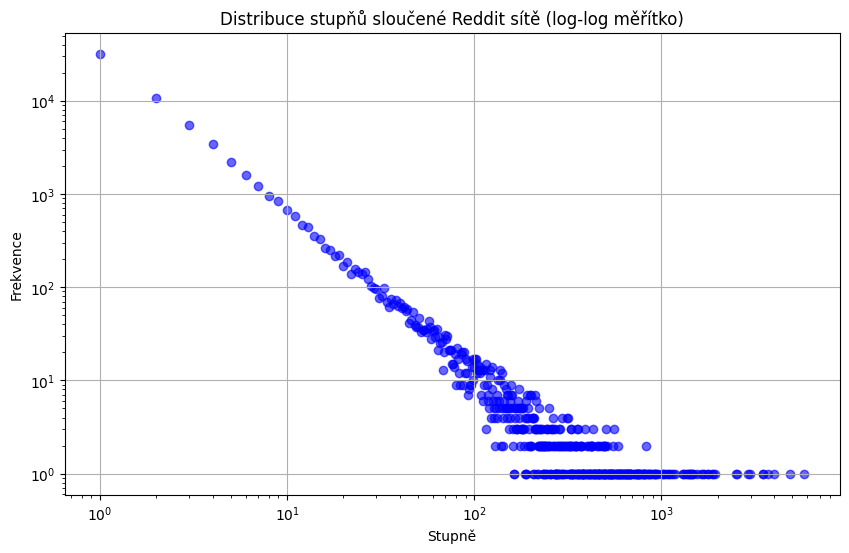

In [27]:
degrees = [degree for _, degree in G_merged.degree()] # pyright: ignore[reportCallIssue]
 
degree_counts = Counter(degrees)
deg, freq = zip(*sorted(degree_counts.items()))

plt.figure(figsize=(10, 6))
plt.scatter(deg, freq, alpha=0.6, color='blue')
plt.title(label='Distribuce stupňů sloučené Reddit sítě (log-log měřítko)')
plt.xlabel('Stupně')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_degree_distribution.png', dpi=300)
plt.show()

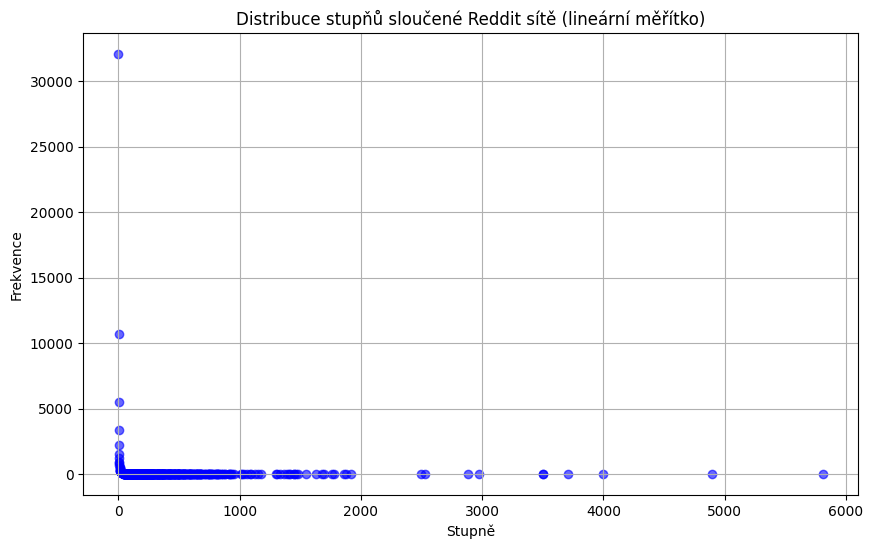

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(deg, freq, alpha=0.6, color='blue')
plt.title('Distribuce stupňů sloučené Reddit sítě (lineární měřítko)')
plt.xlabel('Stupně')
plt.ylabel('Frekvence')
plt.yscale('linear')
plt.xscale('linear')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_degree_distribution_linear.png', dpi=300)
plt.show()

## Velikosti komponent

In [29]:
component_size_counts = Counter(len(c) for c in nx.weakly_connected_components(G_merged))
component_sizes, component_freqs = zip(*sorted(component_size_counts.items()))

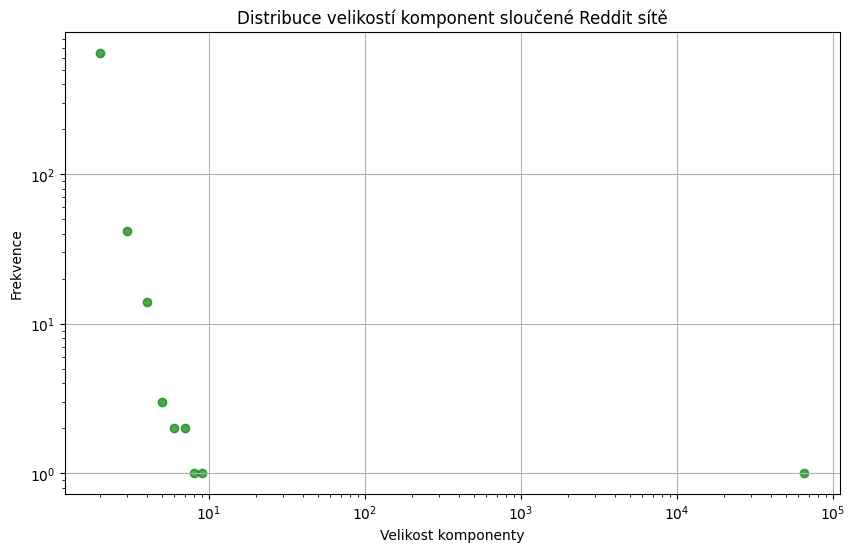

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(component_sizes, component_freqs, alpha=0.7, color='green')
plt.title('Distribuce velikostí komponent sloučené Reddit sítě')
plt.xlabel('Velikost komponenty')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_component_size_distribution.png', dpi=300)
plt.show()

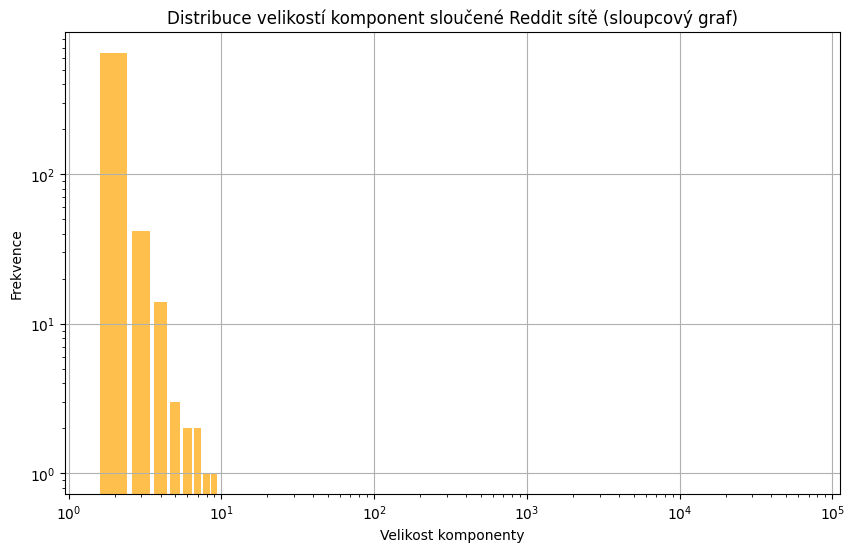

In [31]:
plt.figure(figsize=(10, 6))
plt.bar(component_sizes, component_freqs, color='orange', alpha=0.7)
plt.title('Distribuce velikostí komponent sloučené Reddit sítě (sloupcový graf)')
plt.xlabel('Velikost komponenty')
plt.ylabel('Frekvence')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.savefig(SAVE_PATH / 'reddit_component_size_distribution_bar.png', dpi=300)
plt.show()

# Timestamp analýza

In [32]:
min_timestamp = df_reddit_merged['TIMESTAMP'].min()
max_timestamp = df_reddit_merged['TIMESTAMP'].max()

print(f"Min timestamp: {min_timestamp}")
print(f"Max timestamp: {max_timestamp}")

Min timestamp: 2013-12-31 16:20:20
Max timestamp: 2017-04-30 16:58:21


## Rozdíl mezi minimálním a maximálním timestampem

In [33]:
min_timestamp = pd.to_datetime(min_timestamp)
max_timestamp = pd.to_datetime(max_timestamp)
time_diff = max_timestamp - min_timestamp
time_diff_months = time_diff.days / 30.44  # average days in a month

print(f"Time difference: {time_diff}")
print(f"Time difference in months: {time_diff_months:,.2f}")

Time difference: 1216 days 00:38:01
Time difference in months: 39.95


Analýza časových razítek ukazuje, že data pokrývají období od 31. prosince 2013 do 30. dubna 2017. To znamená, že síť odkazů mezi subreddity byla sledována téměř 3,5 roku. Díky tomu lze zkoumat vývoj a změny v propojení komunit na Redditu v průběhu času, například vznik nových subredditu, změny v aktivitě nebo sezónní trendy.

## Rozdělení si dat na časové úseky

Rozdělení časových intervalů umožňuje analyzovat vývoj sítě v různých obdobích. V této analýze jsou navrženy různé možnosti rozdělení:

- **4 intervaly (čtvrtiny)**: Každý interval pokrývá přibližně čtvrtinu celého časového období.
- **5 intervalů**: Každý interval zahrnuje zhruba 8 měsíců.
- **6 intervalů**: Každý interval pokrývá přibližně 6–7 měsíců (tato varianta je použita v následující analýze).
- **8 intervalů**: Každý interval zahrnuje asi 5 měsíců.

Takové rozdělení umožňuje sledovat změny v propojení komunit, vznik nových subredditu nebo sezónní trendy v síti v různých časových úsecích.

Rozhodli jsme se pro rozdělení na **6 intervalů**, což znamená, že každý interval pokrývá přibližně 6–7 měsíců.


In [34]:
intervals = 6
periods = intervals + 1

## Statistiky pro jednotlivé časové intervaly

In [35]:
intervals = pd.date_range(start=min_timestamp, end=max_timestamp, periods=periods)

df_reddit_merged['TIMESTAMP'] = pd.to_datetime(df_reddit_merged['TIMESTAMP'])
df_reddit_merged['interval'] = pd.cut(df_reddit_merged['TIMESTAMP'], bins=intervals, labels=[f'Interval {i+1}' for i in range(6)], include_lowest=True)  # type: ignore

print(df_reddit_merged['interval'].value_counts().sort_index())

interval
Interval 1     99147
Interval 2    113835
Interval 3    146248
Interval 4    151245
Interval 5    158044
Interval 6    175858
Name: count, dtype: int64


In [36]:
interval_stats = []

for i in range(1, 7):
    label = f'Interval {i}'
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    nodes_split = set(df_split['SOURCE_SUBREDDIT']).union(df_split['TARGET_SUBREDDIT'])
    edges_split = set(zip(df_split['SOURCE_SUBREDDIT'], df_split['TARGET_SUBREDDIT']))

    df_cum = df_reddit_merged[df_reddit_merged['interval'].isin([f'Interval {j}' for j in range(1, i+1)])]
    nodes_cum = set(df_cum['SOURCE_SUBREDDIT']).union(df_cum['TARGET_SUBREDDIT'])
    edges_cum = set(zip(df_cum['SOURCE_SUBREDDIT'], df_cum['TARGET_SUBREDDIT']))

    if i > 1:
        df_prev_cum = df_reddit_merged[df_reddit_merged['interval'].isin([f'Interval {j}' for j in range(1, i)])]
        nodes_prev_cum = set(df_prev_cum['SOURCE_SUBREDDIT']).union(df_prev_cum['TARGET_SUBREDDIT'])
        edges_prev_cum = set(zip(df_prev_cum['SOURCE_SUBREDDIT'], df_prev_cum['TARGET_SUBREDDIT']))
        new_nodes = nodes_split - nodes_prev_cum
        new_edges = edges_split - edges_prev_cum
    else:
        new_nodes = nodes_split
        new_edges = edges_split

    stat = {
        'Interval': label,
        'Nodes': len(nodes_split),
        'Edges': len(edges_split),
        'Cumulative Nodes': len(nodes_cum),
        'Cumulative Edges': len(edges_cum),
        'New Nodes': len(new_nodes),
        'New Edges': len(new_edges),
        'Example New Nodes': ', '.join(list(new_nodes)[:5]) if new_nodes else 'None',
        'Example New Edges': ', '.join([f"{a}->{b}" for a, b in list(new_edges)[:5]]) if new_edges else 'None'
    }
    interval_stats.append(stat)

# Print nicely formatted summary table
df_stats = pd.DataFrame(interval_stats)
print(tabulate(df_stats[['Interval', 'Nodes', 'Edges', 'Cumulative Nodes', 'Cumulative Edges', 'New Nodes', 'New Edges']], headers='keys', tablefmt='simple_grid', showindex=False)) # type: ignore

┌────────────┬─────────┬─────────┬────────────────────┬────────────────────┬─────────────┬─────────────┐
│ Interval   │   Nodes │   Edges │   Cumulative Nodes │   Cumulative Edges │   New Nodes │   New Edges │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 1 │   15978 │   53834 │              15978 │              53834 │       15978 │       53834 │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 2 │   18331 │   62343 │              25475 │             102009 │        9497 │       48175 │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 3 │   22657 │   80475 │              36390 │             160750 │       10915 │       58741 │
├────────────┼─────────┼─────────┼────────────────────┼────────────────────┼─────────────┼─────────────┤
│ Interval 4 │   24629 │   83848 │              46755 │

## Vizualizace statistik časových intervalů

### Vývoj kumulativního počtu uzlů v čase

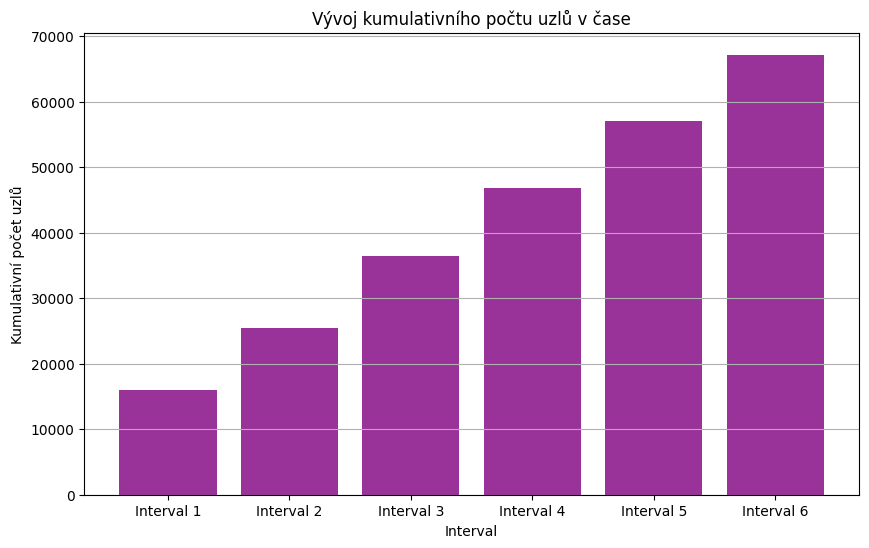

In [37]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Cumulative Nodes'], color='purple', alpha=0.8)
plt.title('Vývoj kumulativního počtu uzlů v čase')
plt.xlabel('Interval')
plt.ylabel('Kumulativní počet uzlů')
plt.grid(True, axis='y')
plt.savefig(SAVE_PATH / 'reddit_cumulative_nodes_bar.png', dpi=300)
plt.show()

### Vývoj počtu uzlů v jednotlivých časových intervalech

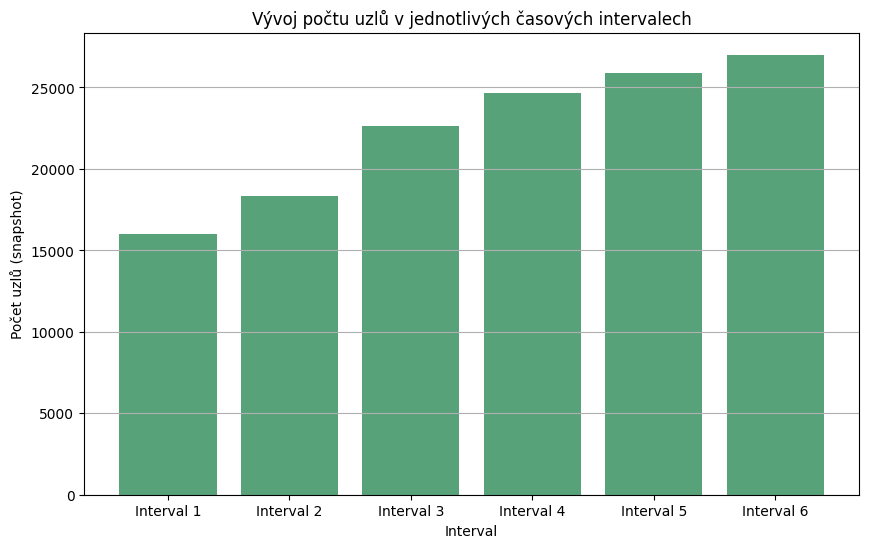

In [38]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Nodes'], color='seagreen', alpha=0.8)
plt.title('Vývoj počtu uzlů v jednotlivých časových intervalech')
plt.xlabel('Interval')
plt.ylabel('Počet uzlů (snapshot)')
plt.grid(True, axis='y')
plt.savefig(SAVE_PATH / 'reddit_snapshot_nodes_bar.png', dpi=300)
plt.show()

### Vývoj kumulativního počtu hran v čase

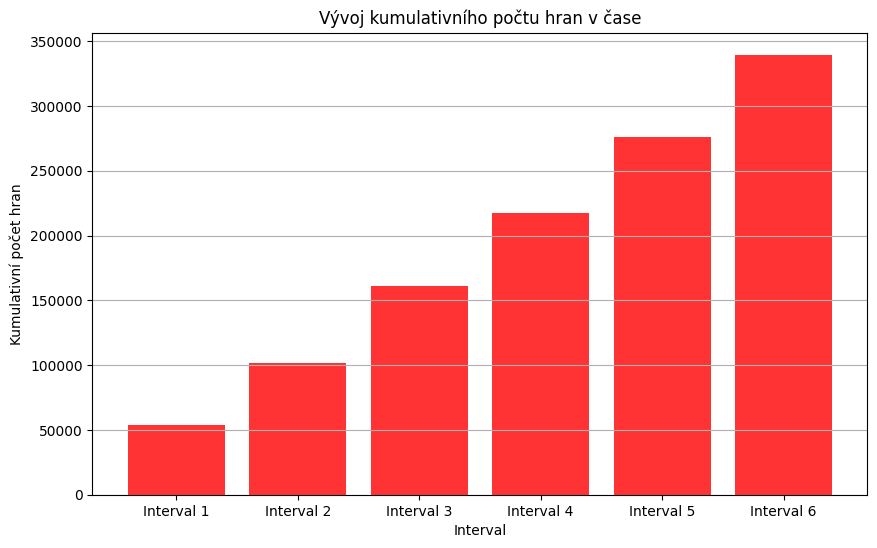

In [39]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Cumulative Edges'], color='red', alpha=0.8)
plt.title('Vývoj kumulativního počtu hran v čase')
plt.xlabel('Interval')
plt.ylabel('Kumulativní počet hran')
plt.grid(True, axis='y')
plt.savefig(SAVE_PATH / 'reddit_cumulative_edges_bar.png', dpi=300)
plt.show()

### Vývoj počtu uzlů v jednotlivých časových intervalech

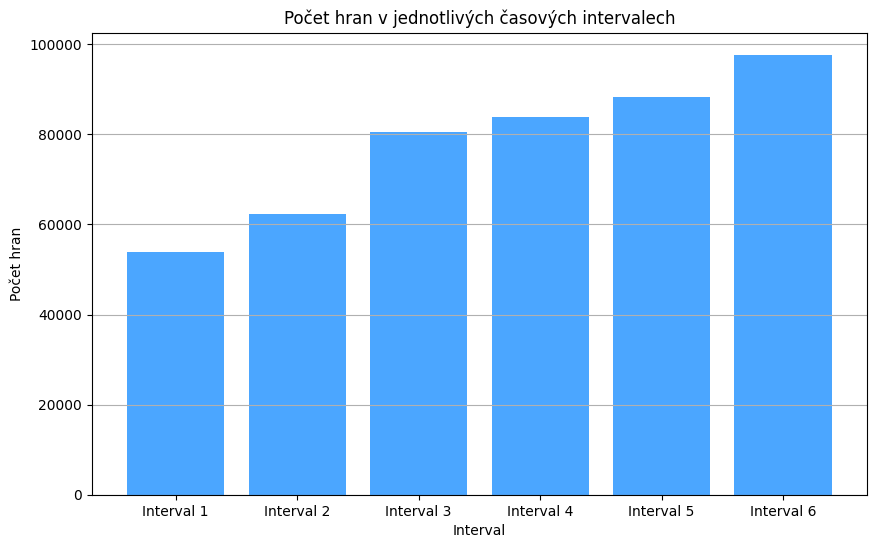

In [40]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['Edges'], color='dodgerblue', alpha=0.8)
plt.title('Počet hran v jednotlivých časových intervalech')
plt.xlabel('Interval')
plt.ylabel('Počet hran')
plt.grid(True, axis='y')
plt.savefig(SAVE_PATH / 'reddit_edges_snapshot_bar.png', dpi=300)
plt.show()

## Základní statistiky sítí vývoje v čase

In [41]:
def compute_interval_stats(args):
    interval_label, df = args

    df_interval = df[df['interval'] <= interval_label]

    nodes_interval = set(df_interval['SOURCE_SUBREDDIT']).union(df_interval['TARGET_SUBREDDIT'])
    edges_interval = set(zip(df_interval['SOURCE_SUBREDDIT'], df_interval['TARGET_SUBREDDIT']))

    G_interval = nx.from_pandas_edgelist(
        df_interval,
        source='SOURCE_SUBREDDIT',
        target='TARGET_SUBREDDIT',
        create_using=nx.DiGraph() # type: ignore
    ) # type: ignore

    num_nodes = len(nodes_interval)
    num_edges = len(edges_interval)
    density = nx.density(G_interval)

    avg_total_degree = (2 * num_edges) / num_nodes if num_nodes else 0
    degrees = [deg for _, deg in G_interval.degree()]
    max_total_degree = max(degrees) if degrees else 0

    clustering_coefficient = nx.average_clustering(G_interval.to_undirected())

    G_u = G_interval.to_undirected()
    common_neighbors_counts = [
        len(list(nx.common_neighbors(G_u, u, v)))
        for u, v in edges_interval
        if u in G_u and v in G_u
    ]

    avg_common_neighbors = np.mean(common_neighbors_counts) if common_neighbors_counts else 0
    max_common_neighbors = max(common_neighbors_counts) if common_neighbors_counts else 0

    num_components = nx.number_weakly_connected_components(G_interval)
    size_biggest_cc = len(max(nx.weakly_connected_components(G_interval), key=len)) if num_nodes else 0

    return {
        'Interval': interval_label,
        'Nodes': num_nodes,
        'Edges': num_edges,
        'Density': density,
        'Average Total Degree': avg_total_degree,
        'Max Total Degree': max_total_degree,
        'Clustering Coefficient': clustering_coefficient,
        'Average Common Neighbors': avg_common_neighbors,
        'Max Common Neighbors': max_common_neighbors,
        'Number of Components': num_components,
        'Size of Biggest Component': size_biggest_cc
    }


In [42]:
timestamp_stats_path = SAVE_PATH / 'reddit_timestamp_stats.csv'

if timestamp_stats_path.exists():
    print("File already exists, loading yearly_stats from CSV.")
    df_timestamp_stats = pd.read_csv(timestamp_stats_path)
    yearly_stats = df_timestamp_stats.to_dict('records')
else:
    print("Computing timestamp-based statistics...")
    interval_labels = df_reddit_merged['interval'].cat.categories if hasattr(df_reddit_merged['interval'], 'cat') else sorted(df_reddit_merged['interval'].unique())

    with Pool(mp.cpu_count()) as pool:
        yearly_stats = pool.map(compute_interval_stats, [(label, df_reddit_merged) for label in interval_labels])
        
    df_timestamp_stats = pd.DataFrame(yearly_stats)
    df_timestamp_stats.to_csv(timestamp_stats_path, index=False)

File already exists, loading yearly_stats from CSV.


In [43]:
df_timestamp_stats = pd.DataFrame(yearly_stats)
df_timestamp_stats = df_timestamp_stats.sort_values('Interval')
df_timestamp_stats

,Interval,Nodes,Edges,Density,Average Total Degree,Max Total Degree,Clustering Coefficient,Average Common Neighbors,Max Common Neighbors,Number of Components,Size of Biggest Component,Average Shortest Path,Diameter
0,Interval 1,15978,53834,0.000211,6.738515,1613,0.167643,8.528904,605,286,15373,4.347273,13
1,Interval 2,25475,102009,0.000157,8.008557,2627,0.191187,12.586458,951,360,24720,4.195289,14
2,Interval 3,36390,160750,0.000121,8.834845,3575,0.202896,16.553319,1265,435,35455,4.118056,12
3,Interval 4,46755,217616,0.000100,9.308780,4356,0.209334,19.754324,1479,505,45679,4.101273,14
4,Interval 5,57100,276270,0.000085,9.676708,5115,0.214170,22.459388,1692,597,55814,4.099280,26
5,Interval 6,67180,339643,0.000075,10.111432,5811,0.216967,25.145014,1892,712,65648,4.075224,26


In [44]:
df_timestamp_stats.to_csv(SAVE_PATH / 'reddit_timestamp_stats.csv', index=False)

### Vývoj průměrné a maximální délky cest v čase

In [45]:
def sssp(node, G):
    lengths = nx.single_source_shortest_path_length(G, node)
    dists = list(lengths.values())
    return sum(dists), max(dists), len(dists) - 1 # sum, max, count of reachable paths

def sssp_stats_interval(args):
    interval_label, df = args
    df_interval = df[df['interval'] <= interval_label]
    G_interval = nx.from_pandas_edgelist(
        df_interval,
        source='SOURCE_SUBREDDIT',
        target='TARGET_SUBREDDIT',
        create_using=nx.DiGraph() # type: ignore
    ) # type: ignore

    nodes = list(G_interval.nodes())

    with Pool() as p:
        results = p.starmap(sssp, [(node, G_interval) for node in nodes])

    sum_dists = sum(r[0] for r in results)
    total_reachable = sum(r[2] for r in results)

    avg_path = sum_dists / total_reachable if total_reachable > 0 else 0
    max_path = max(r[1] for r in results)

    print(f"{interval_label}: avg_path={avg_path:.4f}, max_path={max_path}")
    return avg_path, max_path

In [48]:
if (
    os.path.exists(timestamp_stats_path)
    and {'Interval', 'Average Shortest Path', 'Diameter'}.issubset(pd.read_csv(timestamp_stats_path).columns)
):
    print("SSSP stats already computed for intervals, loading from CSV.")
    df_timestamp_stats = pd.read_csv(timestamp_stats_path)
    print(df_timestamp_stats[['Interval', 'Average Shortest Path', 'Diameter']])

    # load avg_paths and max_paths
    avg_paths = df_timestamp_stats['Average Shortest Path'].tolist()
    max_paths = df_timestamp_stats['Diameter'].tolist()

else:
    print("Computing SSSP stats for each interval...")
    interval_labels = df_timestamp_stats['Interval'].tolist()
    avg_paths = []
    max_paths = []

    for label in interval_labels:
        avg_path, max_path = sssp_stats_interval((label, df_reddit_merged))
        avg_paths.append(avg_path)
        max_paths.append(max_path)

SSSP stats already computed for intervals, loading from CSV.
     Interval  Average Shortest Path  Diameter
0  Interval 1               4.347273        13
1  Interval 2               4.195289        14
2  Interval 3               4.118056        12
3  Interval 4               4.101273        14
4  Interval 5               4.099280        26
5  Interval 6               4.075224        26


In [49]:
df_timestamp_stats['Average Shortest Path'] = avg_paths
df_timestamp_stats['Diameter'] = max_paths
print(df_timestamp_stats[['Interval', 'Average Shortest Path', 'Diameter']])

     Interval  Average Shortest Path  Diameter
0  Interval 1               4.347273        13
1  Interval 2               4.195289        14
2  Interval 3               4.118056        12
3  Interval 4               4.101273        14
4  Interval 5               4.099280        26
5  Interval 6               4.075224        26


In [50]:
df_timestamp_stats

,Interval,Nodes,Edges,Density,Average Total Degree,Max Total Degree,Clustering Coefficient,Average Common Neighbors,Max Common Neighbors,Number of Components,Size of Biggest Component,Average Shortest Path,Diameter
0,Interval 1,15978,53834,0.000211,6.738515,1613,0.167643,8.528904,605,286,15373,4.347273,13
1,Interval 2,25475,102009,0.000157,8.008557,2627,0.191187,12.586458,951,360,24720,4.195289,14
2,Interval 3,36390,160750,0.000121,8.834845,3575,0.202896,16.553319,1265,435,35455,4.118056,12
3,Interval 4,46755,217616,0.000100,9.308780,4356,0.209334,19.754324,1479,505,45679,4.101273,14
4,Interval 5,57100,276270,0.000085,9.676708,5115,0.214170,22.459388,1692,597,55814,4.099280,26
5,Interval 6,67180,339643,0.000075,10.111432,5811,0.216967,25.145014,1892,712,65648,4.075224,26


In [51]:
df_timestamp_stats.to_csv(path_or_buf=SAVE_PATH / 'reddit_timestamp_stats.csv', index=False)

## Počet a velikost komponent v čase

In [52]:
intervals = pd.date_range(start=min_timestamp, end=max_timestamp, periods=periods)
df_reddit_merged['TIMESTAMP'] = pd.to_datetime(df_reddit_merged['TIMESTAMP'])
df_reddit_merged['interval'] = pd.cut(
    df_reddit_merged['TIMESTAMP'],
    bins=intervals, # type: ignore
    labels=[f'Interval {i+1}' for i in range(6)],
    include_lowest=True
)  # type: ignore

In [ ]:
component_size_freqs = []

for label in df_stats['Interval']:
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_split = nx.from_pandas_edgelist(df_split, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT', create_using=nx.DiGraph()) # type: ignore
    sizes = [len(c) for c in nx.weakly_connected_components(G_split)]
    freq = Counter(sizes)
    component_size_freqs.append(freq)


for i, freq in enumerate(component_size_freqs):
    table = [[size, count] for size, count in sorted(freq.items())]
    print(f"Interval {i+1}:")
    print(tabulate(table, headers=["Size", "Frequency"], tablefmt="simple_grid"))
    print()

Interval 1:
┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         264 │
├────────┼─────────────┤
│      3 │          13 │
├────────┼─────────────┤
│      4 │           5 │
├────────┼─────────────┤
│      5 │           2 │
├────────┼─────────────┤
│      8 │           1 │
├────────┼─────────────┤
│  15373 │           1 │
└────────┴─────────────┘

Interval 2:
┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         304 │
├────────┼─────────────┤
│      3 │          28 │
├────────┼─────────────┤
│      4 │           6 │
├────────┼─────────────┤
│  17615 │           1 │
└────────┴─────────────┘

Interval 3:
┌────────┬─────────────┐
│   Size │   Frequency │
├────────┼─────────────┤
│      2 │         360 │
├────────┼─────────────┤
│      3 │          28 │
├────────┼─────────────┤
│      4 │           3 │
├────────┼─────────────┤
│      5 │           4 │
├────────┼─────────────┤
│      7 │           1 │
├────────┼──

## Nejvlivnější uzly v čase

In [55]:
top_centrality_by_interval = []

for label in df_stats['Interval']:
    df_interval = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_interval = nx.from_pandas_edgelist(
        df_interval,
        source='SOURCE_SUBREDDIT',
        target='TARGET_SUBREDDIT',
        create_using=nx.DiGraph() # type: ignore
    ) # type: ignore

    centrality = nx.degree_centrality(G_interval)
    top_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:top_n_centralities_count]
    top_centrality_by_interval.append((label, top_centrality))

# Tabulate results

df_top_centrality = pd.DataFrame([
    {'Interval': label, 'Node': node, 'Centrality': cent}
    for label, top_centrality in top_centrality_by_interval
    for node, cent in top_centrality
])

pivot_table = df_top_centrality.pivot(index='Node', columns='Interval', values='Centrality').fillna(0)
pivot_table_sorted = pivot_table.sort_values(by='Interval 6', ascending=False)
print(tabulate(pivot_table_sorted, headers='keys', tablefmt='simple_grid', floatfmt=".6f")) # type: ignore

┌──────────────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ Node                 │   Interval 1 │   Interval 2 │   Interval 3 │   Interval 4 │   Interval 5 │   Interval 6 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ askreddit            │     0.100958 │     0.091544 │     0.082009 │     0.068621 │     0.065746 │     0.062697 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ the_donald           │     0.000000 │     0.000000 │     0.000000 │     0.000000 │     0.034459 │     0.048995 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ subredditdrama       │     0.080929 │     0.080033 │     0.076492 │     0.057171 │     0.047879 │     0.048402 │
├──────────────────────┼──────────────┼──────────────┼──────────────┼───────────

## Vizualizace všeho možného

### Kombinace 

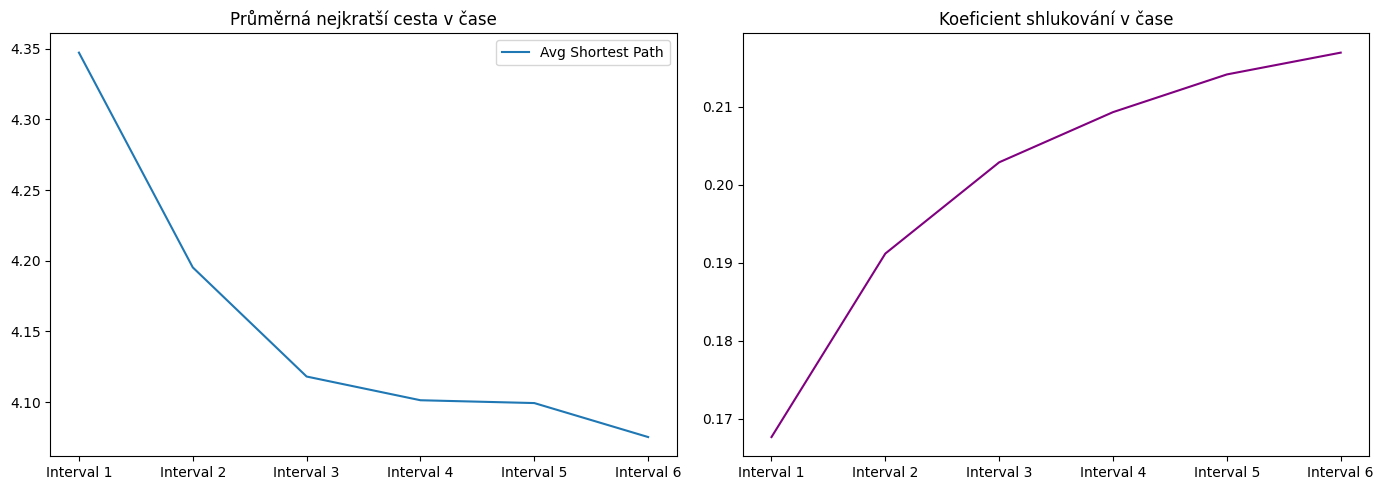

In [56]:
# First row (2 plots)
fig1, axs1 = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Average shortest path & diameter
axs1[0].plot(df_timestamp_stats['Interval'], df_timestamp_stats['Average Shortest Path'], label='Avg Shortest Path')
axs1[0].set_title('Průměrná nejkratší cesta v čase')
axs1[0].legend()

# Subplot 2: Clustering coefficient
axs1[1].plot(df_timestamp_stats['Interval'], df_timestamp_stats['Clustering Coefficient'], color='purple')
axs1[1].set_title('Koeficient shlukování v čase')

plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_mixed_stats_row1.png', dpi=300)
plt.show()

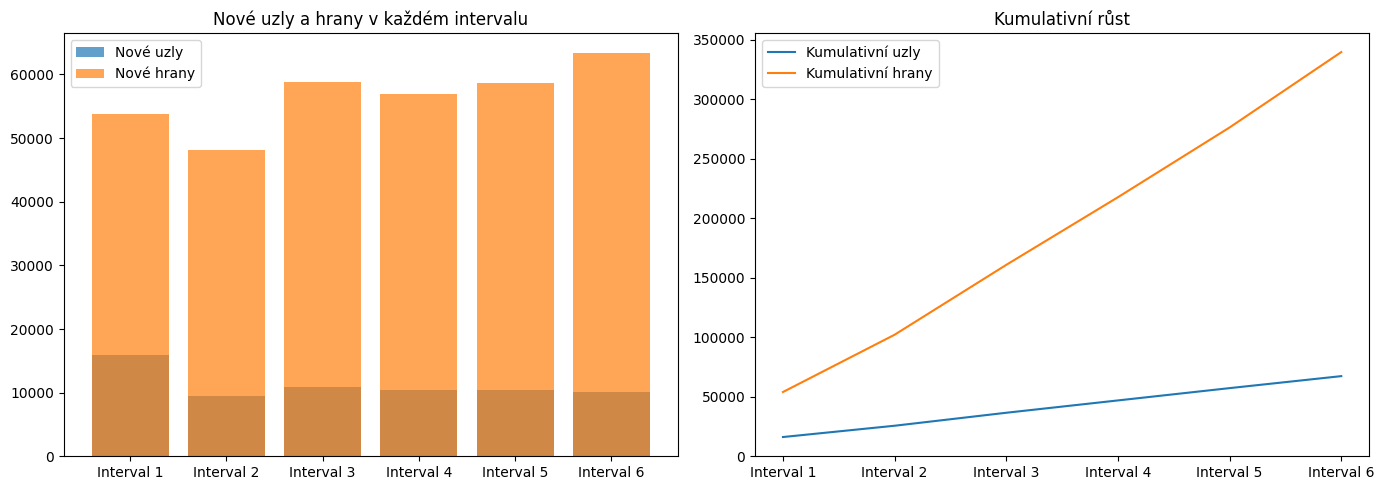

In [57]:
# Second row (2 plots)
fig2, axs2 = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 3: New nodes/edges
axs2[0].bar(df_stats['Interval'], df_stats['New Nodes'], label='Nové uzly', alpha=0.7)
axs2[0].bar(df_stats['Interval'], df_stats['New Edges'], label='Nové hrany', alpha=0.7)
axs2[0].set_title('Nové uzly a hrany v každém intervalu')
axs2[0].legend()

# Subplot 4: Cumulative nodes/edges
axs2[1].plot(df_stats['Interval'], df_stats['Cumulative Nodes'], label='Kumulativní uzly')
axs2[1].plot(df_stats['Interval'], df_stats['Cumulative Edges'], label='Kumulativní hrany')
axs2[1].set_title('Kumulativní růst')
axs2[1].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_mixed_stats_row2.png', dpi=300)
plt.show()

### Centrality top uzlů 

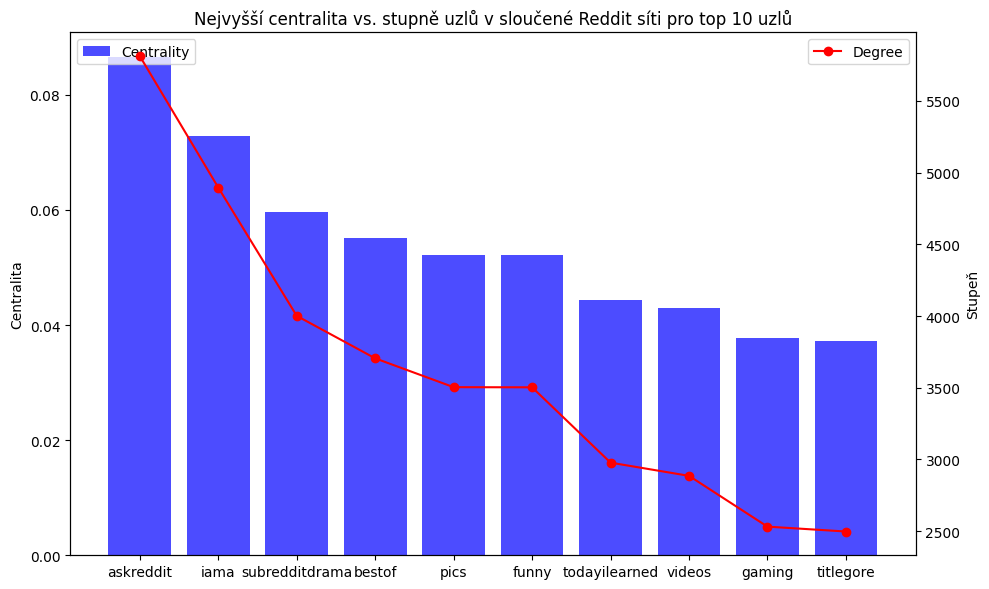

In [58]:
top10 = sorted(nx.degree_centrality(G_merged).items(), key=lambda x: x[1], reverse=True)[:10]
nodes, centralities = zip(*top10)
degrees = [G_merged.degree(n) for n in nodes]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.bar(nodes, centralities, label='Centrality', alpha=0.7, color='blue')
ax2.plot(nodes, degrees, label='Degree', color='red', marker='o')

ax1.set_ylabel('Centralita')
ax2.set_ylabel('Stupeň')

ax1.set_title('Nejvyšší centralita vs. stupně uzlů v sloučené Reddit síti pro top 10 uzlů')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_centrality_vs_degree.png', dpi=300)
plt.show()

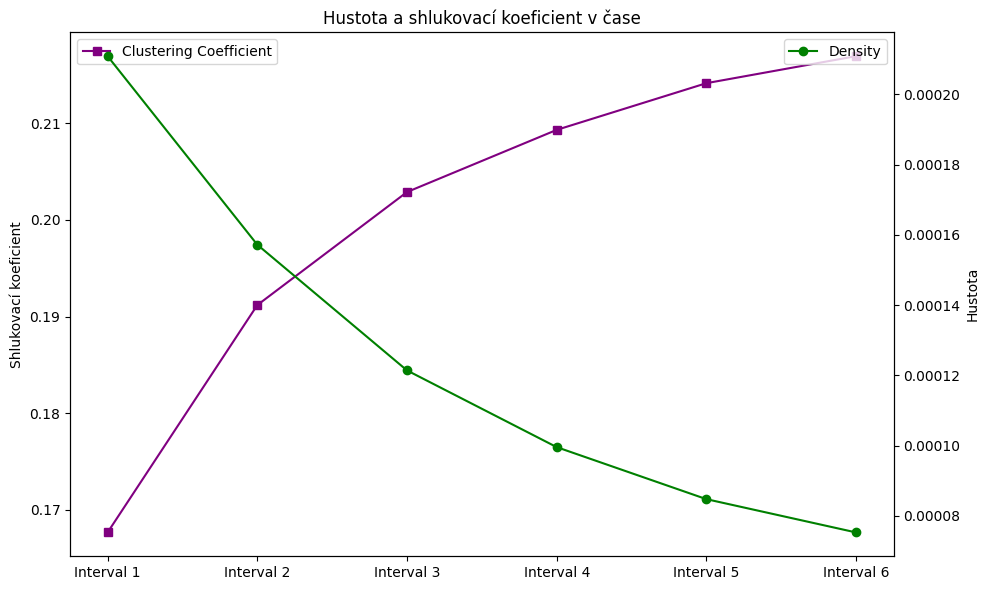

In [59]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Clustering Coefficient'], label='Clustering Coefficient', marker='s', color='purple')
ax2.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Density'], label='Density', marker='o', color='green')

ax1.set_ylabel('Shlukovací koeficient')
ax2.set_ylabel('Hustota')

ax1.set_title('Hustota a shlukovací koeficient v čase')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_density_clustering.png', dpi=300)
plt.show()

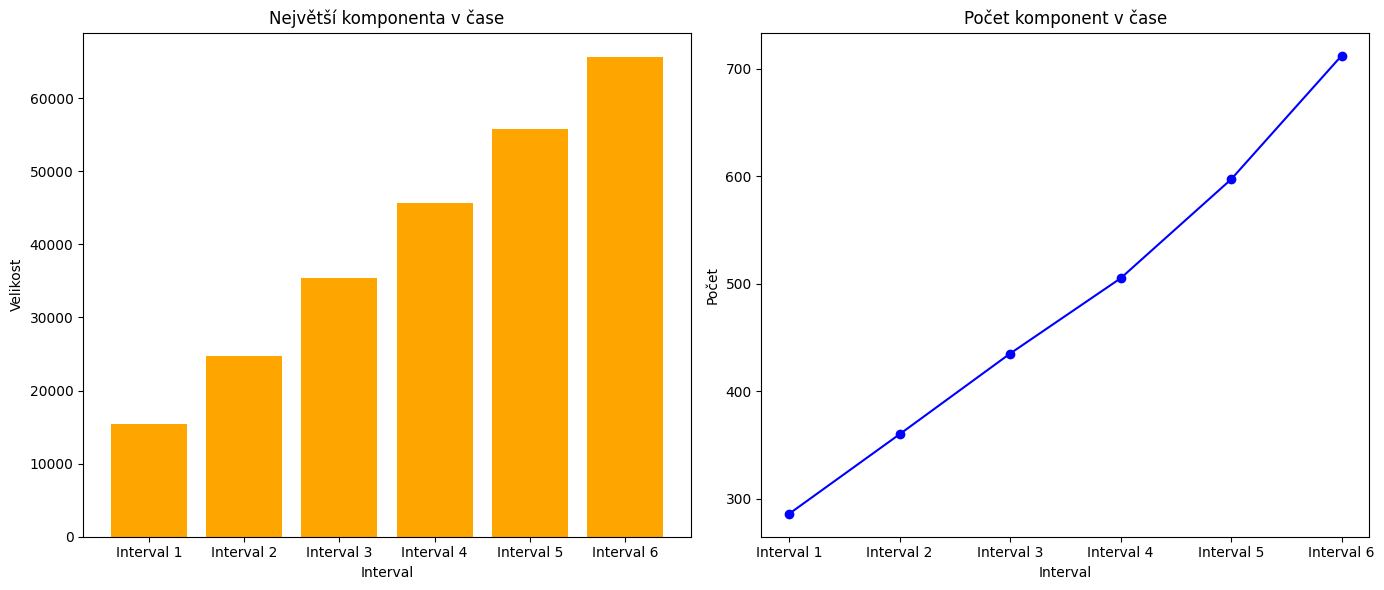

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].bar(df_timestamp_stats['Interval'], df_timestamp_stats['Size of Biggest Component'], color='orange')
axs[0].set_title('Největší komponenta v čase')
axs[0].set_xlabel('Interval')
axs[0].set_ylabel('Velikost')
axs[1].plot(df_timestamp_stats['Interval'], df_timestamp_stats['Number of Components'], marker='o', color='blue')
axs[1].set_title('Počet komponent v čase')
axs[1].set_xlabel('Interval')
axs[1].set_ylabel('Počet')
plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_component_evolution.png', dpi=300)
plt.show()

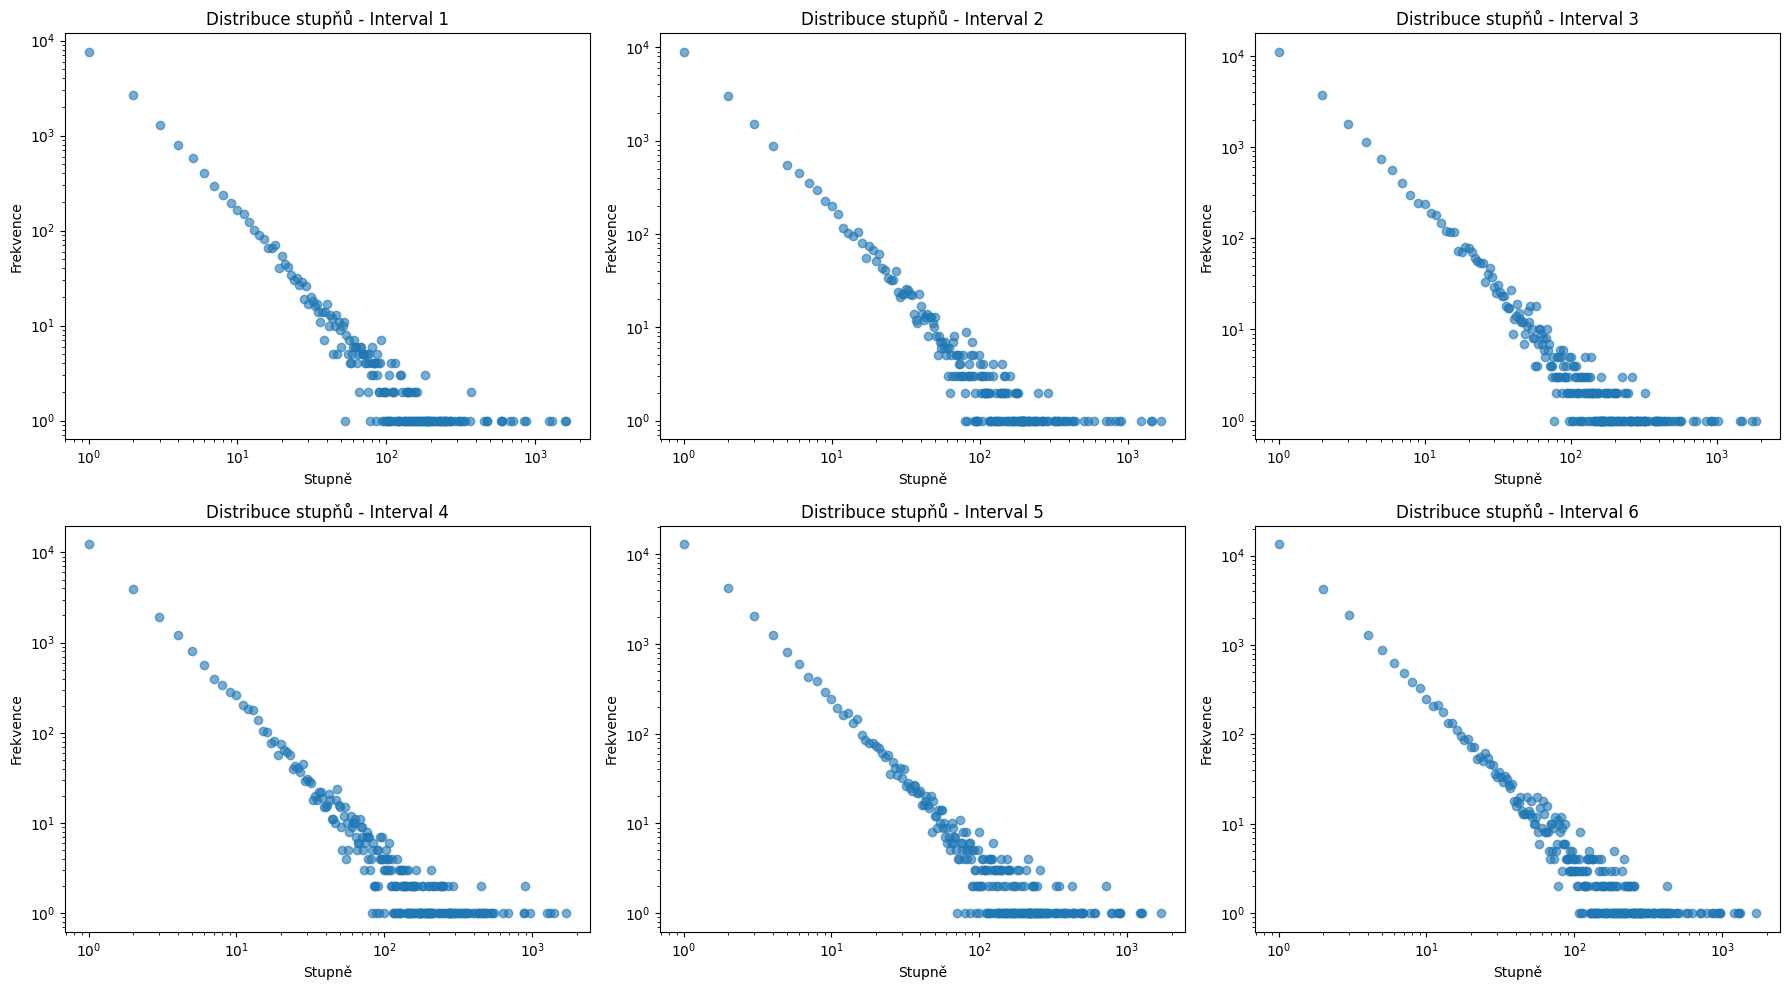

In [61]:
intervals = df_stats['Interval'].tolist()
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
for i, label in enumerate(intervals):
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_split = nx.from_pandas_edgelist(df_split, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT', create_using=nx.DiGraph()) # type: ignore
    degrees = [deg for _, deg in G_split.degree()]
    degree_counts = Counter(degrees)
    deg, freq = zip(*sorted(degree_counts.items()))
    ax = axs[i // 3, i % 3]
    ax.scatter(deg, freq, alpha=0.6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Distribuce stupňů - {label}')
    ax.set_xlabel('Stupně')
    ax.set_ylabel('Frekvence')
plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_degree_distribution_intervals.png', dpi=300)
plt.show()

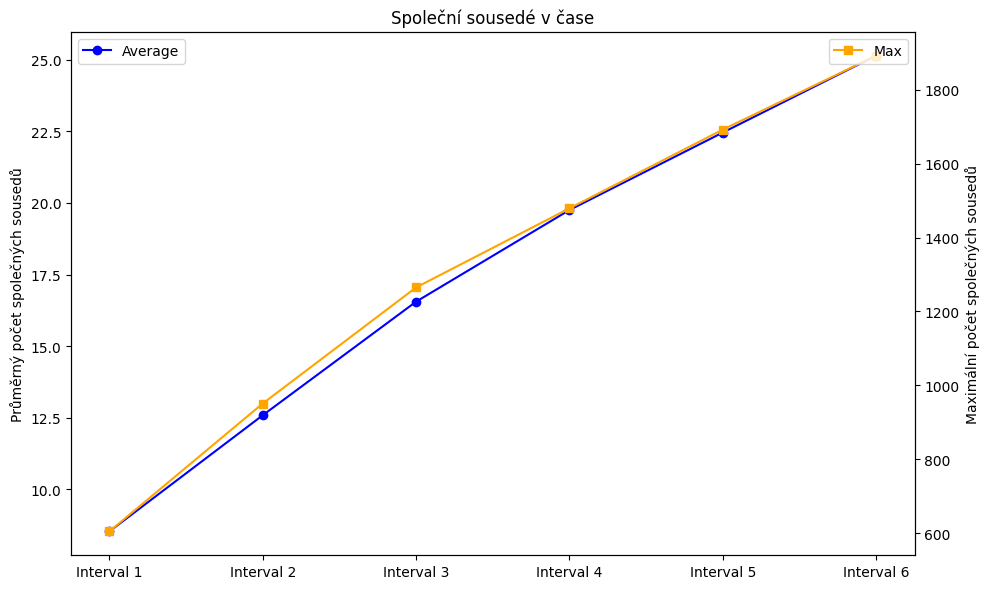

In [62]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Average Common Neighbors'], label='Average', marker='o', color='blue')
ax2.plot(df_timestamp_stats['Interval'], df_timestamp_stats['Max Common Neighbors'], label='Max', marker='s', color='orange')

ax1.set_ylabel('Průměrný počet společných sousedů')
ax2.set_ylabel('Maximální počet společných sousedů')

ax1.set_title('Společní sousedé v čase')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xlabel('Interval')
plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_common_neighbors.png', dpi=300)
plt.show()

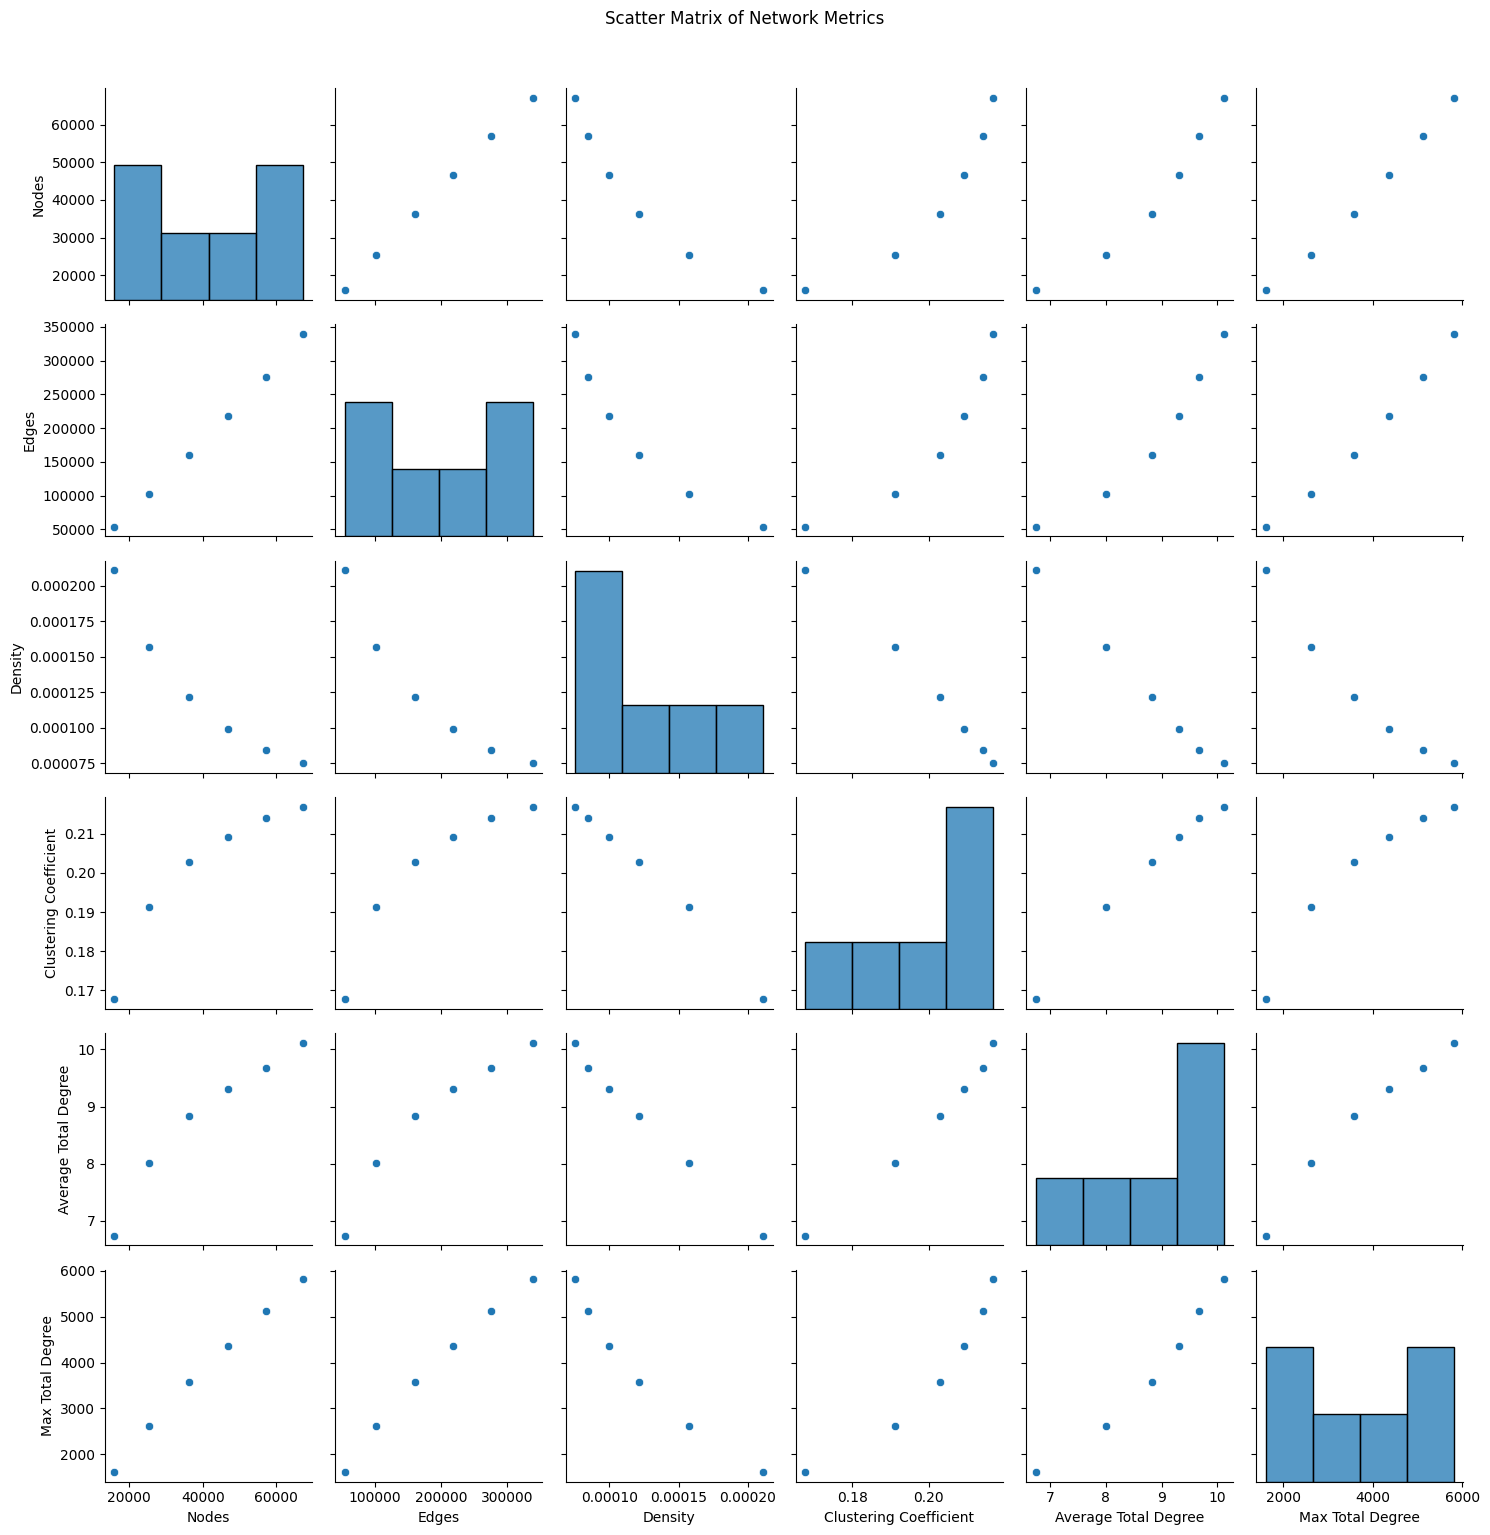

In [63]:
metrics = ['Nodes', 'Edges', 'Density', 'Clustering Coefficient', 'Average Total Degree', 'Max Total Degree']
sns.pairplot(df_timestamp_stats[metrics])
plt.suptitle('Scatter Matrix of Network Metrics', y=1.02)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_scatter_matrix.png', dpi=300)
plt.show()

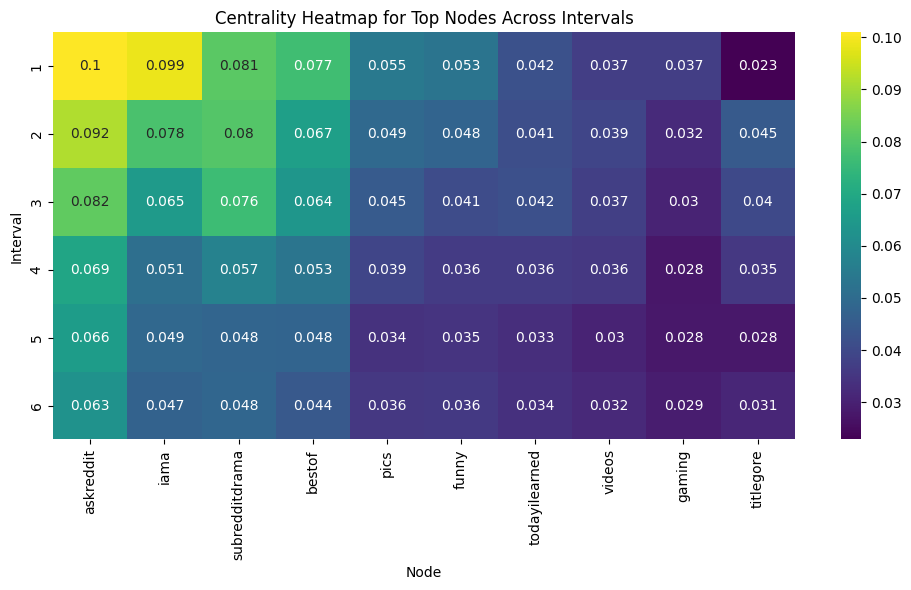

In [64]:
top_nodes = [n for n, _ in top10]
centrality_matrix = []
for i, label in enumerate(intervals):
    df_split = df_reddit_merged[df_reddit_merged['interval'] == label]
    G_split = nx.from_pandas_edgelist(df_split, source='SOURCE_SUBREDDIT', target='TARGET_SUBREDDIT', create_using=nx.DiGraph()) # type: ignore
    centrality = nx.degree_centrality(G_split)
    centrality_matrix.append([centrality.get(n, 0) for n in top_nodes])
plt.figure(figsize=(10, 6))
sns.heatmap(centrality_matrix, annot=True, xticklabels=top_nodes, yticklabels=[str(i+1) for i in range(len(intervals))], cmap='viridis')
plt.title('Centrality Heatmap for Top Nodes Across Intervals')
plt.xlabel('Node')
plt.ylabel('Interval')
plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_centrality_heatmap.png', dpi=300)
plt.show()

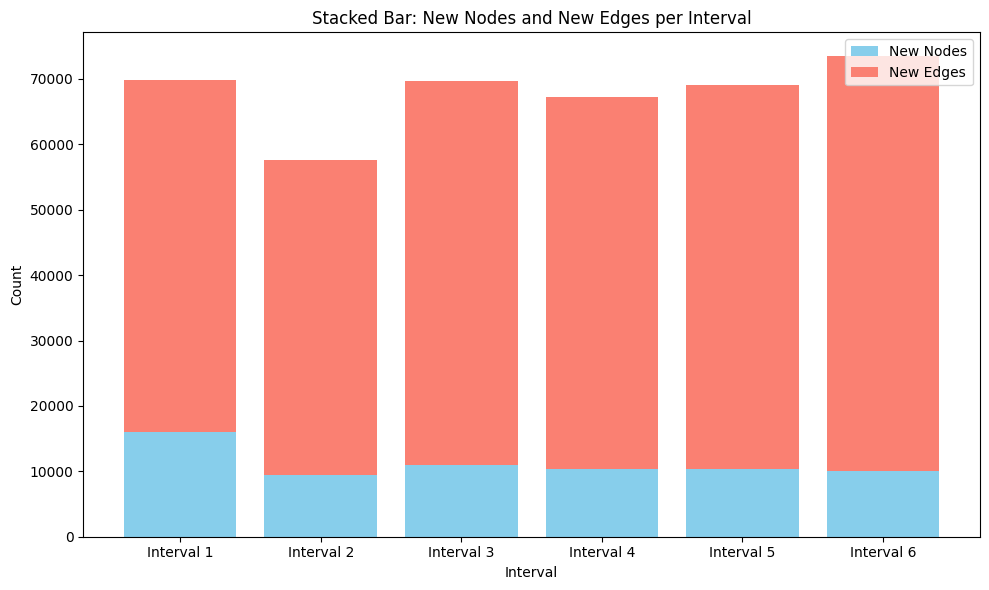

In [65]:
plt.figure(figsize=(10, 6))
plt.bar(df_stats['Interval'], df_stats['New Nodes'], label='New Nodes', color='skyblue')
plt.bar(df_stats['Interval'], df_stats['New Edges'], bottom=df_stats['New Nodes'], label='New Edges', color='salmon')
plt.title('Stacked Bar: New Nodes and New Edges per Interval')
plt.xlabel('Interval')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH / 'reddit_stacked_new_nodes_edges.png', dpi=300)
plt.show()